In [6]:
from _import_scripts import scripts
from scripts.notebook_utils import *
from scripts.tl_output_parsing import MacroOutputStats
from scripts.utils import *
import yaml

MACRO_PATH = "../models/arch/1_macro/basic_analog/" 
macro = {}
SRAM_PATH = f'"{os.path.abspath("../models/memory_cells/sram_example.cell.yaml")}"'
RRAM_PATH = f'"{os.path.abspath("../models/memory_cells/rram_example.cell.yaml")}"'

dnn_layers = {
    "alexnet": 9,
    "vgg16": 17,
    "dpt_large": 228,
    "gpt2_medium": 146,
    "mobilebert": 410,
    "vision_transformer": 99,
    "resnet-50": 54,
    "bert-large": 193,
    "efficientnetb-7": 274
}

# Define the architecture
array_sizes = 128
path_list = [SRAM_PATH, RRAM_PATH]
tech_node = 32
DNN = "alexnet"
dnn_layer = dnn_layers.get(DNN, None)
time = "fast"


In [7]:
def create_layer_directory(base_output_dir: str, architecture: str, layer: int) -> str:
    layer_dir = os.path.join(base_output_dir, f"{architecture}_layer_{layer}")
    if not os.path.exists(layer_dir):
        os.makedirs(layer_dir)
    return layer_dir

num_layers = 1

def run_map(
    spec: tl.Specification,
    arch: str,
    accelergy_verbose: bool = False,
) -> dict:
    output_dir = get_run_dir()
    # Just use the directory name if it causes error
    base_output_dir = os.path.dirname(output_dir)
    base_output_dir = os.path.join(base_output_dir, arch)
    global num_layers

    mapper_result = None

    if num_layers < dnn_layer:
        # Create a directory for the current layer
        layer_dir = create_layer_directory(base_output_dir, arch, num_layers)
        # print(f"Layer directory: {layer_dir}")
        num_layers += 1

        run_prefix = f"{layer_dir}/timeloop-mapper"
        mapper_result = tl.call_mapper(
            specification=spec,
            output_dir=layer_dir,
            log_to=os.path.join(output_dir, f"{run_prefix}.log"),
        )
        if accelergy_verbose:
            tl.call_accelergy_verbose(
                specification=spec,
                output_dir=layer_dir,
                log_to=os.path.join(output_dir, "accelergy.log"),
            )

    if mapper_result is None:
        # Handle case when mapper_result is not assigned (num_layers >= 17)
        # Raise an error, return a default value
        print("Warning: mapper_result is not assigned. num_layers >= 17")
        return {}

    return MacroOutputStats.from_output_stats(mapper_result)

import re

def extract_range(line):
    match = re.search(r'\[(\d+):(\d+)(,\d+)?\)', line)
    if match:
        start = int(match.group(1))
        end = int(match.group(2))
        return end - start
    return None

def read_and_compute_multiplication(filename, i):
    filename = f"../outputs/{filename}/{filename}_layer_{i+1}/timeloop-mapper.map.txt"
    with open(filename, 'r') as file:
        lines = file.readlines()

    start_searching = False
    ranges = []

    for line in lines:
        # Start searching when 'inter_macro_in_system_spatial' is found
        if "inter_macro_in_system_spatial" in line:
            start_searching = True
        
        # Stop searching if we leave the 'inter_macro_in_system_spatial' section
        elif start_searching and "inter_" in line and "inter_macro_in_system_spatial" not in line:
            break

        # If we are in the 'inter_macro_in_system_spatial' section, look for the ranges
        if start_searching:
            if "for" in line:
                range_size = extract_range(line)
                if range_size is not None:
                    ranges.append(range_size)
            elif line.strip() == "":  # Exit the section on an empty line
                break

    # Compute the multiplication of all ranges, or return 1 if no ranges were found
    if not ranges:
        print(f"All macro: 1")
        return 1

    result = 1
    for size in ranges:
        result *= size
        print(f"Size: {size}")
    print(f"All macro: {result}")
    return result


def extract_layer_number(folder_name):
    match = re.search(r'layer_(\d+)', folder_name)
    return int(match.group(1)) if match else float('inf')

def extract_outputs(model):
    
    output_dir = "../outputs/" + model + "/" 
    print(output_dir)

    print ("Model \t Energy/inference (J) \t Area (mm2) \t Throughput (inf/s)")
    #for model in models:    
    throughput = 0   
    energy = 0
    area = 0
    cycles = 0
    folders = sorted([folder for folder in os.listdir(output_dir) if model in folder], key=extract_layer_number)
    area_per_many_macro = 0
    area_layer = 0
    j = 0
    total_sum = 0
    total_adc_area = 0  # Total area for ADC across all layers
    total_other_areas = {}  # Dictionary to store total areas for other components
    total_col_area = 0
    total_row_area = 0
    total_cim_unit_area = 0
    total_area = 0
    total_macro = 0
    
    for folder in folders:
        total = 0
        if model in folder:
            print(f"Processing layer: {folder}")
            # print(folder)
            if os.path.isdir(output_dir + folder):
                stat_file = output_dir + folder + "/timeloop-mapper.stats.txt"
                art_file = output_dir + folder + "/timeloop-mapper.ART.yaml"
        
                with open(stat_file, 'r') as f:
                    energy_stat = [line for line in f if line.startswith("Energy:")][0]
                    energy_uj = energy_stat.split(' ')[1] # uJ
                    energy += float(energy_uj)
                    # print(f"Energy for this layer: {float(energy_uj)} uj")
                
                with open(stat_file, 'r') as f:
                    cycle_stat = [line for line in f if line.startswith("Cycles:")][0]                  
                    cycle = cycle_stat.split(' ')[1] 
                    cycles += float(cycle)
                    
            if j < 16:
                with open(art_file, 'r') as file:
                    data = yaml.safe_load(file)
                
                    # Extract and print the name, area, number of entries, and ratio for non-zero areas
                for table in data['ART']['tables']:
                    name = table.get('name')
                    area = table.get('area')
                    if area != 0:
                        # Simplify the name for the output
                        if 'system_top_level.' in name:
                            name = name.split('system_top_level.')[-1]
                        
                        # Extract the number of entries from the name
                        if '[' in name:
                            name_part, entries_part = name.split('[')
                            number_of_entries = entries_part.split('..')[1].replace(']', '')
                            name = name_part.strip()
                        else:
                            number_of_entries = 'Unknown'
                        
                        macro = read_and_compute_multiplication(model, j)
                        # Calculate total ratio
                        if number_of_entries != 'Unknown' and number_of_entries.isdigit():
                            total_ratio = (area / 4096) * macro * int(number_of_entries)
                        else:
                            total_ratio = 0
                        
                        total += total_ratio
                           
                        # Accumulate area for ADC or other components
                        if 'adc' in name.lower():
                            total_adc_area += total_ratio
                        else:
                            if name not in total_other_areas:
                                total_other_areas[name] = 0
                            total_other_areas[name] += total_ratio
            
                        print(f"{name.replace('_', ' ')} area: {area}, number of {name}: {number_of_entries}, \ntotal {name.replace('_', ' ')} area: ({area}*{number_of_entries}/4096) * macro = {total_ratio}\n")
                j += 1 
                total_sum += total
                total_macro += macro
                print(f"Total Area for layer {j}: {total}\n")
                print(f"Total Macro for layer {j}: {total_macro}\n")
            print(f"Total Area for all layers: {total_sum}")
            print(f"Total Area for ADC across all layers: {total_adc_area}")
    
    # Print total area for other components
    for component, area in total_other_areas.items():
        print(f"Total Area for {component.replace('_', ' ')} across all layers: {area}")
        # print(component.replace('_', ' '))
        if component.replace('_', ' ') ==  "column drivers":
            total_col_area = area
        elif component.replace('_', ' ') ==  "row drivers":
            total_row_area = area
        else:
            total_cim_unit_area = area
                                
    energy *= 1e-6 # conver to J
    total_area = total_sum * 1e-6 # mm2
    throughput = 1 / (cycles * 1e-7) # s

    total_adc_area = total_adc_area * 1e-6 # mm2
    total_col_area = total_col_area * 1e-6 # mm2
    total_row_area = total_row_area * 1e-6 # mm2
    total_cim_unit_area = total_cim_unit_area * 1e-6 # mm2
    print("\n")
    print(f"Total Area for ADC across all layers: {total_adc_area}")
    print(f"Total Area for column driver across all layers: {total_col_area}")
    print(f"Total Area for row driver across all layers: {total_row_area}")
    print(f"Total Area for cim unit across all layers: {total_cim_unit_area}")
    print(f"Total Macro across all layers: {total_macro}")
    print ("{} \t {:.2e} \t {:.2f} \t {:.2e}".format(model, energy, total_area, throughput))
    
    return total_area, total_adc_area, total_col_area, total_row_area, total_cim_unit_area, total_macro, energy, throughput




Running alexnet with 128 x 128 SRAM with 32 nm in fast scenario
Computes for layer 1: 137259.375
Computes for layer 2: 437400.0
Computes for layer 3: 219024.0
Computes for layer 4: 292032.0
Computes for layer 5: 194688.0
Computes for layer 6: 73728.0
Computes for layer 7: 32768.0
Computes for layer 8: 8000.0

Overall energy for DNN alexnet: 1000000000000030.6 fJ
total_per_energy[SRAM][0]: 0.4731585716327145
total_per_energy[SRAM][1]: 0.002873882599514137
total_per_energy[SRAM][2]: 0.5223797653260508
total_per_energy[SRAM][3]: 0.0015877804417205336


Running alexnet with 128 x 128 RRAM with 32 nm in fast scenario
Computes for layer 1: 137259.375
Computes for layer 2: 437400.0
Computes for layer 3: 219024.0
Computes for layer 4: 292032.0
Computes for layer 5: 194688.0
Computes for layer 6: 73728.0
Computes for layer 7: 32768.0
Computes for layer 8: 8000.0

Overall energy for DNN alexnet: 1000000000000037.0 fJ
total_per_energy[RRAM][0]: 0.44791666666616303
total_per_energy[RRAM][1]: 1.12

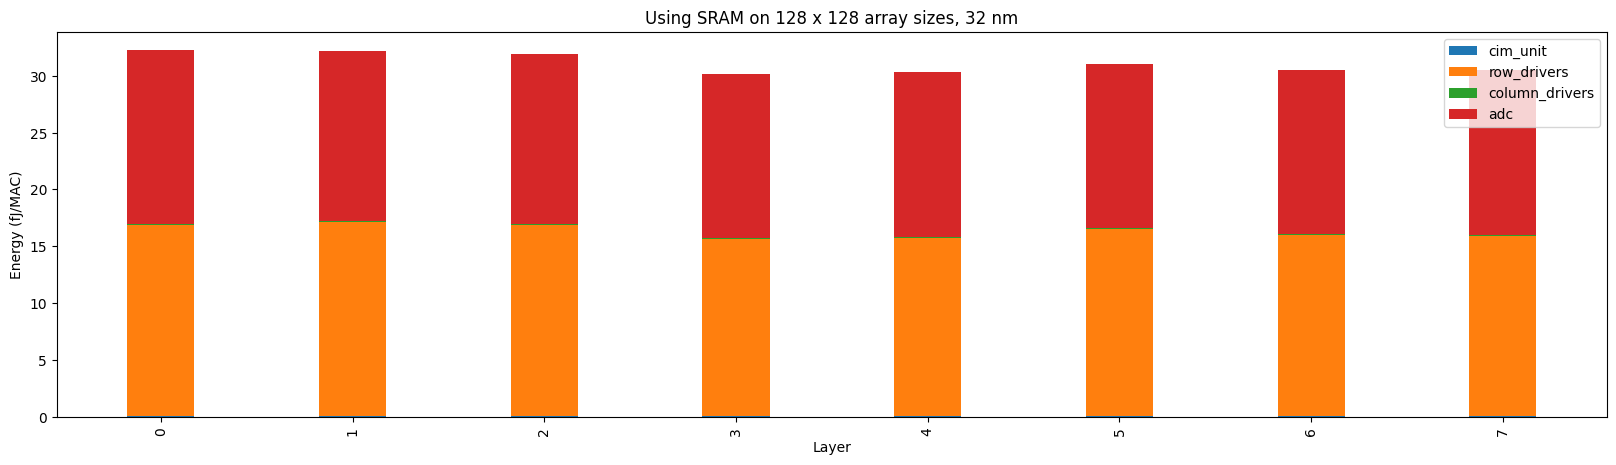

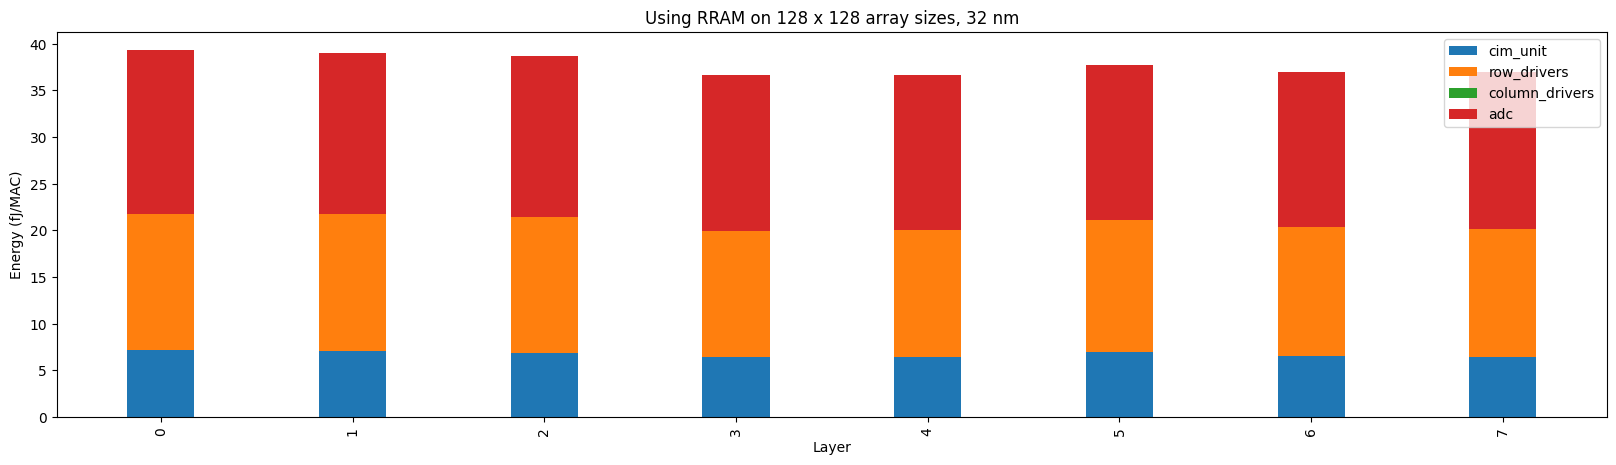

In [8]:
total_per_energy = {}

for path in path_list:
    arch = f"{path.split('/')[-1].split('_')[0].upper()}_{DNN}_{array_sizes}"
    print(f"\nRunning {DNN} with {array_sizes} x {array_sizes} {path.split('/')[-1].split('_')[0].upper()} with {tech_node} nm in {time} scenario")

    num_layers = 1

    def run_dnn(dnn: str, layer: str, array_sizes: int, variables):
        print(f"{layer} ", end="", flush=True)
        spec = get_spec(
            "basic_analog",
            # Weight-stationary, dummy buffer on top to hold inputs & outputs, many
            # macros to ensure we can fit all weights.
            system="ws_dummy_buffer_many_macro",
            # Set the DNN and layer
            dnn=dnn,
            layer=layer,
        )
    
        # Do NOT generate a maximum-utilization workload; we're running a DNN
        # workload.
        spec.variables["MAX_UTILIZATION"] = False
    
        # Use a larger array to ensure we can fit all weights
        spec.architecture.find("column").spatial.meshX = array_sizes
        spec.architecture.find("row").spatial.meshY = array_sizes
    
        spec.variables.update(variables)
        output_stats = run_map(spec, arch)
        
        # Print computes for the layer
        macro_output_stats = MacroOutputStats.from_output_stats(output_stats)
        print(f"Computes for layer {int(layer) + 1}: {macro_output_stats.computes}")
        global macro
        macro[layer] = macro_output_stats.computes
        return output_stats
    
    layers = [f for f in os.listdir(f"../models/workloads/{DNN}") if f != "index.yaml" and f.endswith(".yaml")]
    layers = sorted(layers)
    print(f"Running: ", end="")
    
    # Parallel/Delayed is used to multiprocess. Equivalent to running the following
    # code in serial:
    results = joblib.Parallel(n_jobs=None)(
        joblib.delayed(run_dnn)(DNN, layer.split(".")[0], array_sizes, 
                                  {
                                      "CELL_CONFIG": path,
                                      "BITS_PER_CELL": 1 if path == SRAM_PATH else 4,
                                      "CIM_UNIT_WIDTH_CELLS": 4 if path == SRAM_PATH else 1,
                                      "IS_SRAM": path == SRAM_PATH,
                                      "TECHNOLOGY": tech_node,
                                      "ADC_RESOLUTION": 4 if path == SRAM_PATH else 6,
                                      "GLOBAL_CYCLE_SECONDS": 1e-7 if time == "fast" else 1e-4,
                                  }
                                 ) for layer in layers
    )
    print("")
    for r in results:
        r.clear_zero_energies()
    
    #Initialize overall_energy
    energy_layer = [0] * 16
    result = 0
    
    total_adc_energy = 0.0
    total_col_energy = 0.0
    total_row_energy = 0.0
    total_cim_unit_energy = 0.0
    # Calculate overall energy
    for r in results:
    
        per_component_energy = r.per_compute("per_component_energy")
        total_energy_per_layer = sum(per_component_energy.values()) * 1e15  # Convert to fJ
        total_adc_energy += per_component_energy.get('adc', 0.0)
        total_col_energy += per_component_energy.get('column_drivers', 0.0)
        total_row_energy += per_component_energy.get('row_drivers', 0.0)
        total_cim_unit_energy += per_component_energy.get('cim_unit', 0.0)
    
        total_adc_energy = total_adc_energy * 1e15
        total_col_energy = total_col_energy * 1e15
        total_row_energy = total_row_energy * 1e15
        total_cim_unit_energy = total_cim_unit_energy * 1e15
        total_energy = total_adc_energy + total_col_energy + total_row_energy + total_cim_unit_energy
    
        total_adc_energy = total_adc_energy/total_energy
        total_col_energy = total_col_energy/total_energy
        total_row_energy = total_row_energy/total_energy
        total_cim_unit_energy = total_cim_unit_energy/total_energy

        total_per_energy[path] = [total_adc_energy, total_col_energy, total_row_energy, total_cim_unit_energy]
        
    # Display overall energy
    print(f"Overall energy for DNN {DNN}: {total_energy} fJ")

    for i in range(4):
        print(f"total_per_energy[{path.split('/')[-1].split('_')[0].upper()}][{i}]: {total_per_energy[path][i]}")
    print() 
    
    # Display an energy breakdown for each layer as a bar chart. Display normalized per-MAC and per-layer energy.
    fig, ax = plt.subplots(figsize=(20, 5))
    
    bar_stacked(
        {i: r.per_compute("per_component_energy") * 1e15 for i, r in enumerate(results)},
        title= f"Using {path.split('/')[-1].split('_')[0].upper()} on {array_sizes} x {array_sizes} array sizes, {tech_node} nm",
        xlabel="Layer",
        ylabel="Energy (fJ/MAC)",
        ax=ax,
    )

In [9]:
display_markdown(
    """
### Calculating Area in fast scenario

"""
)
total_area = [0] * 2
total_adc_area = [0] * 2
total_col_area = [0] * 2
total_row_area = [0] * 2
total_cim_unit_area = [0] * 2
total_macro = [0] * 2
energy = [0] * 2
throughput = [0] * 2
total_area[0], total_adc_area[0], total_col_area[0], total_row_area[0], total_cim_unit_area[0], total_macro[0], energy[0], throughput[0] = extract_outputs(f"SRAM_{DNN}_128_fast")
total_area[1], total_adc_area[1], total_col_area[1], total_row_area[1], total_cim_unit_area[1], total_macro[1], energy[1], throughput[1] = extract_outputs(f"RRAM_{DNN}_128_fast")



### Calculating Area in fast scenario



../outputs/SRAM_alexnet_128_fast/
Model 	 Energy/inference (J) 	 Area (mm2) 	 Throughput (inf/s)
Processing layer: SRAM_alexnet_128_fast_layer_1
Size: 3
All macro: 3
adc area: 28515.1, number of adc: 4096, 
total adc area: (28515.1*4096/4096) * macro = 85545.29999999999

Size: 3
All macro: 3
column drivers area: 1054.65, number of column_drivers: 4096, 
total column drivers area: (1054.65*4096/4096) * macro = 3163.9500000000003

Size: 3
All macro: 3
row drivers area: 928.496, number of row_drivers: 4096, 
total row drivers area: (928.496*4096/4096) * macro = 2785.488

Size: 3
All macro: 3
cim unit area: 0.32768, number of cim_unit: 67108864, 
total cim unit area: (0.32768*67108864/4096) * macro = 16106.127360000002

Total Area for layer 1: 107600.86535999998

Total Macro for layer 1: 3

Total Area for all layers: 107600.86535999998
Total Area for ADC across all layers: 85545.29999999999
Processing layer: SRAM_alexnet_128_fast_layer_2
Size: 3
Size: 13
All macro: 39
adc area: 28515.1, nu

In [10]:
print(total_area)
print(total_adc_area)
print(total_col_area)
print(total_row_area)
print(total_cim_unit_area)
print(total_macro)
print(energy)
print(throughput)

[185.4321579704, 162.1928090288]
[147.423067, 153.83748599999998]
[5.4525405, 2.2800372099999997]
[4.800324319999999, 2.6057575500000003]
[27.7562261504, 3.4695282688]
[5170, 5170]
[2.2396999999999996e-05, 2.7171999999999997e-05]
[2344.665885111372, 2344.665885111372]


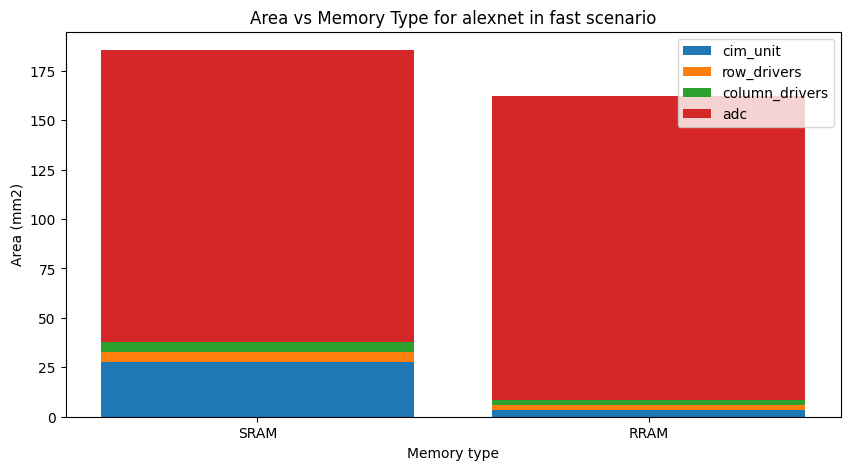

In [11]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5)) 
# array_sizes = ['32', '64', '128', '256']
path = ['SRAM', 'RRAM']

x = np.arange(len(path))

# Stack bars
ax.bar(path, total_cim_unit_area, label='cim_unit')
ax.bar(path, total_row_area, bottom=total_cim_unit_area, label='row_drivers')
ax.bar(path, total_col_area, bottom=np.array(total_cim_unit_area) + np.array(total_row_area), label='column_drivers')
ax.bar(path, total_adc_area, bottom=np.array(total_cim_unit_area) + np.array(total_row_area) + np.array(total_col_area), label='adc')

# Labels and title
ax.set_title(f"Area vs Memory Type for {DNN} in fast scenario")
ax.set_xlabel("Memory type")
ax.set_ylabel("Area (mm2)")
# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(path)

ax.legend()

# Show plot
plt.show()

In [12]:
for path in path_list:
    print(f"Memory Type: {path.split('/')[-1].split('_')[0].upper()}")
    # For each component index (0 to 3)
    for i in range(4):
        print(f"total_per_energy[{path.split('/')[-1].split('_')[0].upper()}][{i}]: {total_per_energy[path][i]}")
    print() 

Memory Type: SRAM
total_per_energy[SRAM][0]: 0.4731585716327145
total_per_energy[SRAM][1]: 0.002873882599514137
total_per_energy[SRAM][2]: 0.5223797653260508
total_per_energy[SRAM][3]: 0.0015877804417205336

Memory Type: RRAM
total_per_energy[RRAM][0]: 0.44791666666616303
total_per_energy[RRAM][1]: 1.124999999998736e-12
total_per_energy[RRAM][2]: 0.37109374999958317
total_per_energy[RRAM][3]: 0.1809895833331288



In [13]:
display_markdown(
    """
### Calculating the energy

"""
)

path_list = [SRAM_PATH, RRAM_PATH]
total_adc_energy = [0] * 2
total_col_energy = [0] * 2
total_row_energy = [0] * 2
total_cim_unit_energy = [0] * 2
for j in range(len(energy)):
    if j == 0:
        for i in range(4):
            if i == 0:
                total_adc_energy[j] = total_per_energy[path_list[0]][i] * energy[j]
            elif i == 1:
                total_col_energy[j] = total_per_energy[path_list[0]][i] * energy[j]
            elif i == 2:
                total_row_energy[j] = total_per_energy[path_list[0]][i] * energy[j]
            else:
                total_cim_unit_energy[j] = total_per_energy[path_list[0]][i] * energy[j]
    else:
        for i in range(4):
            if i == 0:
                total_adc_energy[j] = total_per_energy[path_list[1]][i] * energy[j]
            elif i == 1:
                total_col_energy[j] = total_per_energy[path_list[1]][i] * energy[j]
            elif i == 2:
                total_row_energy[j] = total_per_energy[path_list[1]][i] * energy[j]
            else:
                total_cim_unit_energy[j] = total_per_energy[path_list[1]][i] * energy[j]

    
print("Total ADC Energy:", total_adc_energy)
print("Total Column Energy:", total_col_energy)
print("Total Row Energy:", total_row_energy)
print("Total CIM Unit Energy:", total_cim_unit_energy)


### Calculating the energy



Total ADC Energy: [1.0597332528857906e-05, 1.217079166665298e-05]
Total Column Energy: [6.436634858131812e-08, 3.056849999996565e-17]
Total Row Energy: [1.1699739604007557e-05, 1.0083359374988672e-05]
Total CIM Unit Energy: [3.5561518553214783e-08, 4.917848958327775e-06]


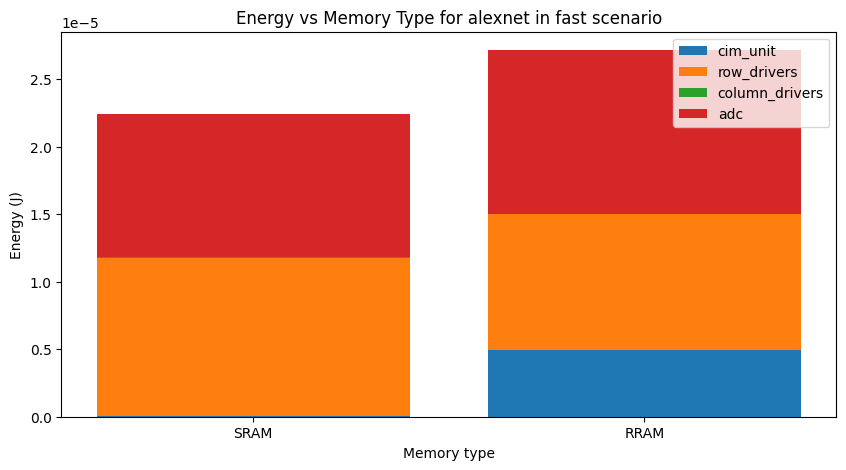

In [14]:
import matplotlib.pyplot as plt
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5)) 
path = ['SRAM', 'RRAM']

# x = np.arange(len(array_sizes))

# Stack bars
ax.bar(path, total_cim_unit_energy, label='cim_unit')
ax.bar(path, total_row_energy, bottom=total_cim_unit_energy, label='row_drivers')
ax.bar(path, total_col_energy, bottom=np.array(total_cim_unit_energy) + np.array(total_row_energy), label='column_drivers')
ax.bar(path, total_adc_energy, bottom=np.array(total_cim_unit_energy) + np.array(total_row_energy) + np.array(total_col_energy), label='adc')

# Labels and title
ax.set_title(f"Energy vs Memory Type for {DNN} in fast scenario")
ax.set_xlabel("Memory type")
ax.set_ylabel("Energy (J)")
# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(path)

ax.legend()

# Show plot
plt.show()


### Plot the Throughput



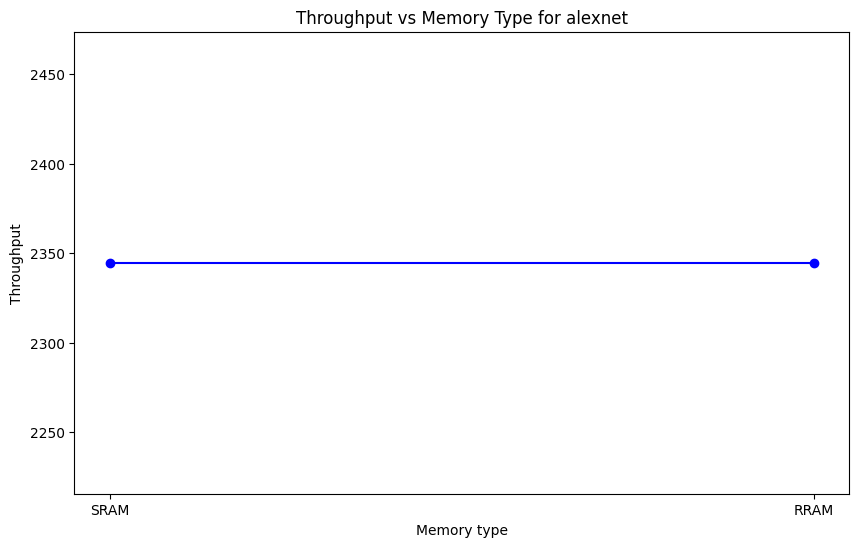

In [15]:
display_markdown(
    """
### Plot the Throughput

"""
)
import matplotlib.pyplot as plt

# Data
path = ['SRAM', 'RRAM']
x = np.arange(len(path))
# Plotting the line graph
plt.figure(figsize=(10, 6))
plt.plot(path, throughput, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Memory type')
plt.ylabel('Throughput')
plt.title(f'Throughput vs Memory Type for {DNN}')
plt.grid(False)
plt.xticks(x, path) 
# Show plot
plt.show()


### Plot the Number of Macros



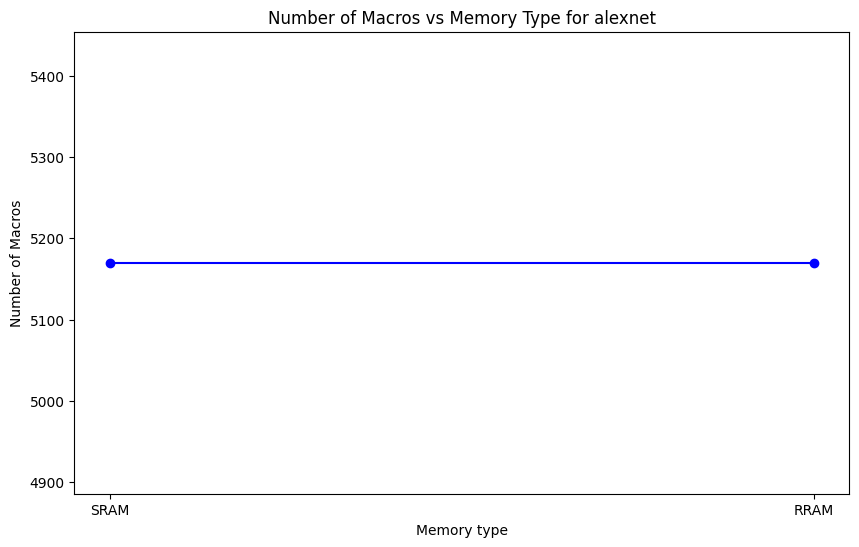

In [17]:
display_markdown(
    """
### Plot the Number of Macros

"""
)
import matplotlib.pyplot as plt

# Data
path = ['SRAM', 'RRAM']
x = np.arange(len(path))
# Plotting the line graph
plt.figure(figsize=(10, 6))
plt.plot(path, total_macro, marker='o', linestyle='-', color='b')

# Adding labels and title
plt.xlabel('Memory type')
plt.ylabel('Number of Macros')
plt.title(f'Number of Macros vs Memory Type for {DNN}')
plt.grid(False)
plt.xticks(x, path) 
# Show plot
plt.show()